In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt

In [3]:
def std_basis(n, i):
    # Return i-th standard basis vector.
    out = np.zeros(n)
    out[i] = 1
    return out

def _grad_central_diff(f, x0, h):
    n = x0.shape[0]
    return np.array([
        (f(x0 + h * std_basis(n, i)) - f(x0 - h * std_basis(n, i))) / (2*h)
        for i in range(n)
    ])
    
def _grad_finite_diff(f, x0, h):
    n = x0.shape[0]
    f0 = f(x0)
    return np.array([
        (f(x0 + h * std_basis(n, i)) - f0) / h
        for i in range(n)
    ])
    

METHODS = {
    'central': _grad_central_diff,
    'finite_diff': _grad_finite_diff,
}
    

def grad(f, x0, h, method=None):
    if method not in METHODS:
        raise ValueError(f"Unknown method: '{method}'. Must be one of {METHODS.keys()}")
    return METHODS[method](f, x0, h)
    

In [4]:
@dataclass
class ErrorInfo:
    # Stepsizes
    h: np.ndarray
    x0: np.ndarray
    # RMS Error in numeric versus
    # ||grad_numeric(f, x0, h) - grad_analytic(f, x0)||_2
    errors_by_method: dict


In [5]:
def test_gradient(f, grad_f, x0):
    # Check whether that the given analytic gradient grad_f is 
    # close to the gradient computed numerically from f at a given
    # point x0.
    h = np.logspace(0, -15, 31)
    all_errors = {}
    for method in METHODS.keys():
        errors = np.full_like(h, np.nan)
        for i, h_i in enumerate(h):
            numeric_grad = grad(f, x0, h_i, method)
            analytic_grad = grad_f(x0)
            errors[i] = np.linalg.norm(numeric_grad - analytic_grad)
        all_errors[method] = errors

    
    return ErrorInfo(h=h, x0=x0, errors_by_method=all_errors)


def plot_errors(info, func_name):
    plt.figure()
    for method, error in info.errors_by_method.items():
        # if method != "central":
        #     continue
        plt.loglog(info.h, error, '-o', label=method)
    plt.legend()
    plt.xlabel("h (stepsize)")
    plt.ylabel("error")
    plt.title(f"Numeric gradient error for {func_name} at {np.round(info.x0, 2)}")
        
        
        
            
    

In [6]:
x0 = np.random.uniform(0, 1, 10)
print(f"{np.round(x0, 2)}")

[0.98 0.01 0.07 0.6  0.27 0.45 0.96 0.48 0.64 0.32]


In [7]:
help(np.log1p)

Help on ufunc in module numpy:

log1p = <ufunc 'log1p'>
    log1p(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Return the natural logarithm of one plus the input array, element-wise.

    Calculates ``log(1 + x)``.

    Parameters
    ----------
    x : array_like
        Input values.
    out : ndarray, None, or tuple of ndarray and None, optional
        A location into which the result is stored. If provided, it must have
        a shape that the inputs broadcast to. If not provided or None,
        a freshly-allocated array is returned. A tuple (possible only as a
        keyword argument) must have length equal to the number of outputs.
    where : array_like, optional
        This condition is broadcast over the input. At locations where the
        condition is True, the `out` array will be set to the ufunc result.
        Elsewhere, the `out` array will retain its original value.
        Note that if an uninitialized `

In [8]:
@dataclass
class Linear:
    a: float
    b: float

    def f(self, x):
        return self.a * x + self.b

    def grad(self, x):
        return self.a

@dataclass
class Affine:
    A: np.ndarray
    b: np.ndarray
    
    def f(self, x):
        return self.A @ x + b
        
    def grad(self, x):
        return A

@dataclass
class Quadratic:
    a: float
    b: float
    c: float 
    def f(self, x):
        return self.a * x**2 + self.b * x + self.c

    def grad(self, x):
        return 2 * self.a * x + self.b

@dataclass
class Cubic:
    c: np.ndarray
    
    def __init__(self, c):
        self.c = np.asarray(c)
        assert self.c.shape[0] == 4
        
    def f(self, x):
        return np.vdot(self.c, np.r_[x**3, x**2, x, 1])

    def grad(self, x):
        return np.vdot(self.c[:-1], np.r_[3 * x**2, 2*x, 1])


def sigmoid(a):
    return 1 / (1 + np.exp(-a))
    
class LogLikelihoodLogistic:
    X: np.ndarray  # shape NxP where N is number of data points
    y: np.ndarray # shape N vector of labels

    def __init__(self, X, y):
        self.N, self.P = X.shape
        self.y = np.asarray(y)
        assert self.y.shape[0] == self.N
        self.X = X

    def alpha(self, i, w):
        return -self.y[i] * np.vdot(w, self.X[i])
        
    def f(self, w):
        return np.sum(
            [np.log1p(np.exp(self.alpha(i, w)))
             for i in range(self.N)]
        )

    def grad(self, w):
        return -np.sum(
            [sigmoid(self.alpha(i, w)) * self.y[i] * self.X[i]
             for i in range(self.N)], axis=0)

    def __repr__(self):
        return f"Logistic(X=array[({self.N}, {self.P})], y=array[{self.N}]"
            
            
                                                  


                                                
            
        
    

In [9]:
np.random.seed(0)
N = 10
P = 5
X = np.random.uniform(0, 10, (N, P))
y = np.where(np.random.uniform(0, 1, N) < 0.5, -1, 1)
w0_log = np.random.uniform(-5, 5, P)

In [10]:
ll = LogLikelihoodLogistic(X, y)

In [11]:
ll.grad(w0_log)

array([-16.05094154, -20.18317976, -16.26958269, -20.3891377 ,
        -5.13480658])

In [12]:
ll.alpha(3, w0_log)

np.float64(-45.295562331485286)

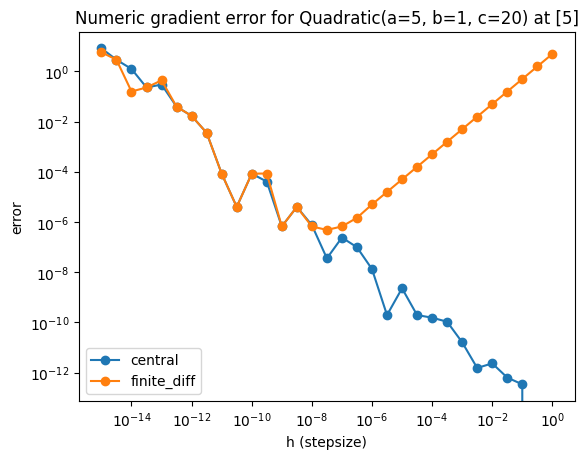

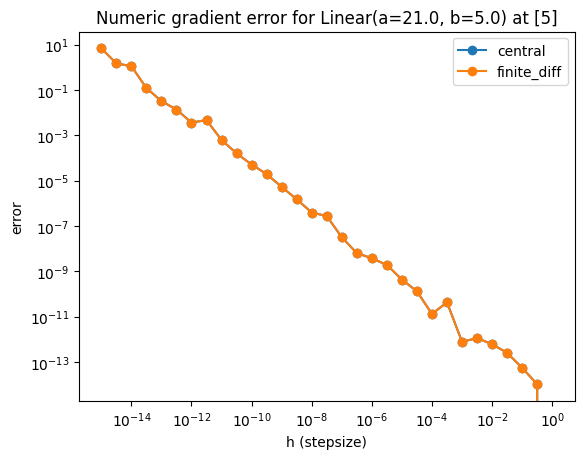

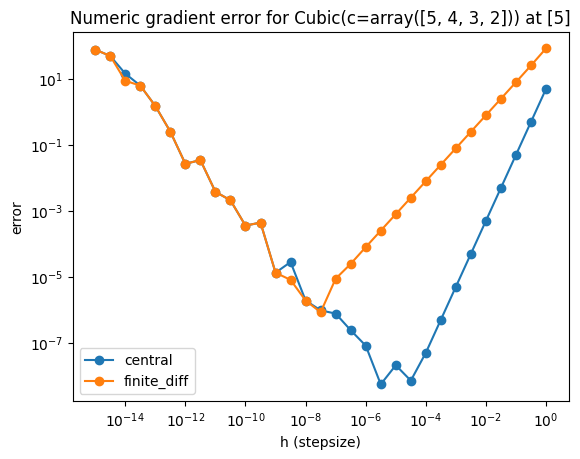

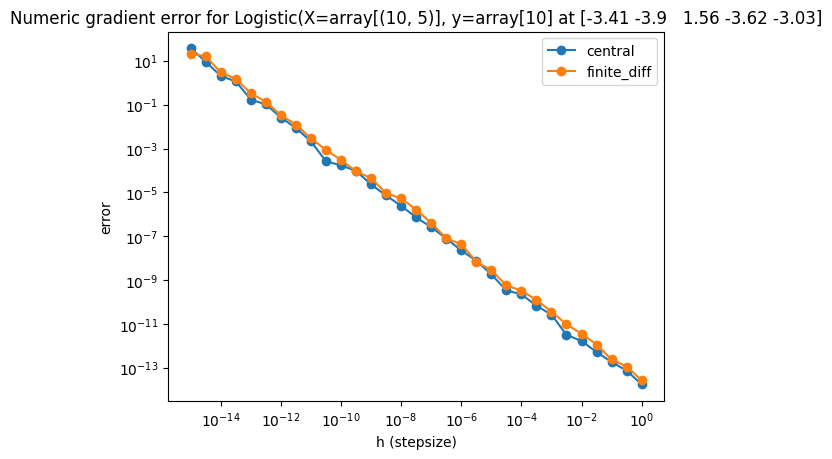

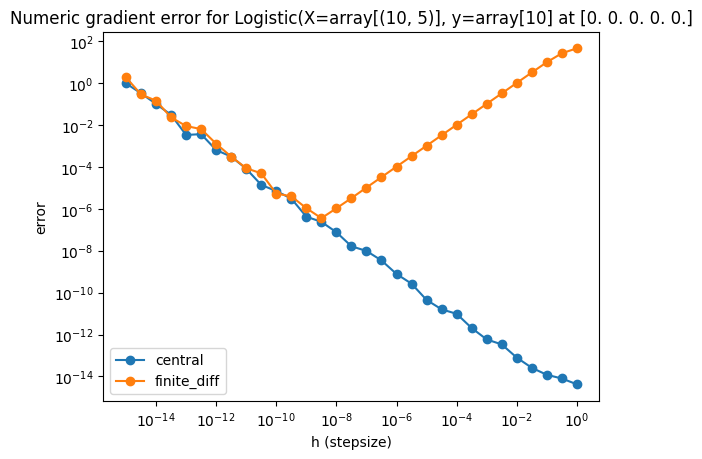

In [13]:
x0_1d = np.array([5])
for x0, func in [
    (x0_1d, Quadratic(5, 1, 20)),
    (x0_1d, Linear(21.0, 5.)),
    (x0_1d, Cubic([5, 4, 3, 2])),
    (w0_log, LogLikelihoodLogistic(X, y)),
    (np.zeros(P), LogLikelihoodLogistic(X, y))
]:
    e = test_gradient(func.f, func.grad, x0)
    plot_errors(e, str(func))

In [14]:
@dataclass
class SolverResult:
    solution: np.ndarray
    converged: bool
    steps: np.ndarray

    
def gradient_descent(f, grad, x0, stepsize, tol=1e-6, maxiters=int(1e3)):
    
    N = x0.shape[0]
    steps = np.full((maxiters, N), np.nan)
    
    f0 = f(x0)
    
    for i in range(maxiters):
        steps[i] = x0
        
        # Move in the descent direction
        x1 = x0 - grad(x0) * stepsize
        f1 = f(x1)
        
        if abs(f1 - f0) < tol:
            # Converged successfully
            return SolverResult(x1, True, steps[:i+1])
        # Update variables for next loop iteration
        f0 = f1
        x0 = x1
    # maxiters was exceeded without reaching tolerance
    return SolverResult(x0, False, steps)
    
        
        
        

In [15]:
np.vdot(np.ones(5), np.ones(5))

np.float64(5.0)

In [16]:
def descent_with_search(f, grad, x0, c=1e-4, rho=0.9, t0=1e-3, tol=1e-6, maxiters=int(1e3)):
    N = x0.shape[0]
    steps = np.full((maxiters, N), np.nan)

    f0 = f(x0)

    t = t0
    for i in range(maxiters):
        steps[i] = x0

        p = -grad(x0)
        norm2_p = np.vdot(p, p)
        while f(x0 + t * p) > f0 - c * t * norm2_p:
            t *= rho
        x1 = x0 + t * p
        f1 = f(x1)

        if abs(f1 - f0) < tol:
            return SolverResult(x1, True, steps[:i+1])

        f0 = f1
        x0 = x1
        t *= 2
    return SolverResult(x0, False, steps)
        
        

In [17]:
np.random.seed(0)
M = 100
N = 50
A = np.random.uniform(0, 10, (M,N))
b = np.ones(M)
# x_star = np.linalg.inv(A.T @ A) @ A.T @ b
x_star, _, rank, _ = np.linalg.lstsq(A, b)

In [18]:
def f(x):
    return 1/2 * np.linalg.norm(A @ x - b)

def grad_f(x):
    return A.T @ (A @ x - b)

In [19]:
def spectral_norm(A):
    return np.linalg.svd(A, compute_uv=False)[0]

In [20]:
x0 = np.zeros(N)
stepsize = 1 / spectral_norm(A)**2
res = gradient_descent(f, grad_f, x0, stepsize, tol=1e-10, maxiters=10000)
err_gd = np.linalg.norm(res.steps - x_star, axis=1)
print(res.converged)

True


In [21]:
x0 = np.zeros(N)
stepsize = 1 / spectral_norm(A)**2
res = descent_with_search(f, grad_f, x0, tol=1e-10, maxiters=10000)
err_search = np.linalg.norm(res.steps - x_star, axis=1)
print(res.converged)

True


In [22]:
err.shape

NameError: name 'err' is not defined

In [23]:
np.linalg.norm(res.solution - x_star)

np.float64(0.0003070558361769401)

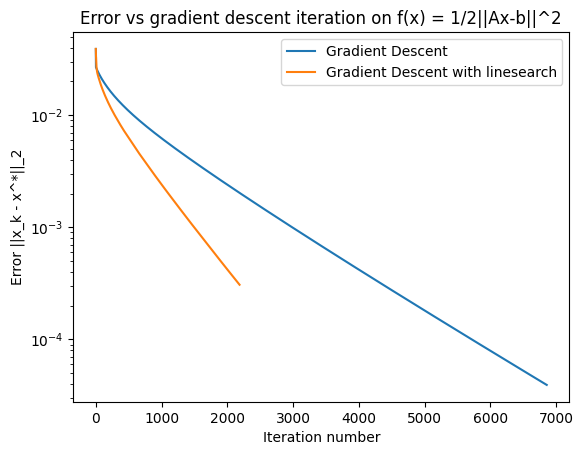

In [26]:
fig = plt.figure()
plt.semilogy(err_gd, label="Gradient Descent")
plt.semilogy(err_search, label="Gradient Descent with linesearch")
plt.title("Error vs gradient descent iteration on f(x) = 1/2||Ax-b||^2")
plt.xlabel("Iteration number")
plt.ylabel("Error ||x_k - x^*||_2")
plt.legend()

In [27]:
fig = plt.figure()
plt.semilogy(err)
plt.title("Error vs gradient descent iteration on f(x) = 1/2||Ax-b||^2")
plt.xlabel("Iteration number")
plt.ylabel("Error ||x_k - x^*||_2")

NameError: name 'err' is not defined

<Figure size 640x480 with 0 Axes>

In [28]:
help(np.linalg.lstsq)

Help on _ArrayFunctionDispatcher in module numpy.linalg:

lstsq(a, b, rcond=None)
    Return the least-squares solution to a linear matrix equation.

    Computes the vector `x` that approximately solves the equation
    ``a @ x = b``. The equation may be under-, well-, or over-determined
    (i.e., the number of linearly independent rows of `a` can be less than,
    equal to, or greater than its number of linearly independent columns).
    If `a` is square and of full rank, then `x` (but for round-off error)
    is the "exact" solution of the equation. Else, `x` minimizes the
    Euclidean 2-norm :math:`||b - ax||`. If there are multiple minimizing
    solutions, the one with the smallest 2-norm :math:`||x||` is returned.

    Parameters
    ----------
    a : (M, N) array_like
        "Coefficient" matrix.
    b : {(M,), (M, K)} array_like
        Ordinate or "dependent variable" values. If `b` is two-dimensional,
        the least-squares solution is calculated for each of the `K` c

In [29]:
x_star1 = np.linalg.lstsq(A, b)[0]
print(x_star1.shape)
np.linalg.norm(x_star - x_star1)

(50,)


np.float64(0.0)

In [30]:
res.steps[:3]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.0071347 , 0.00765119, 0.00724509, 0.0070451 , 0.00801688,
        0.00701808, 0.00754411, 0.00662673, 0.00777006, 0.00788586,
        0.00716686, 0.00774651, 0.0069718 , 0.00694001, 0.00736524,
        0.0067616 , 0.00673909, 0.00723171, 0.00771104, 0.00792093,
        0.00773154, 0.00756765, 0.00727987, 0.0

In [31]:
np.all(np.isnan(res.steps), axis=1)

array([False, False, False, ..., False, False, False], shape=(2187,))

In [32]:
x_star

array([ 4.06589042e-03,  9.72980188e-03,  1.08367383e-02,  2.59261982e-03,
        5.26620850e-03,  3.95022154e-03,  1.38996882e-03, -1.60734936e-03,
        4.39915611e-03,  3.77924632e-03, -6.97298025e-04,  2.15450157e-03,
        8.68869838e-03, -2.03899673e-05,  1.16643241e-03,  9.54755088e-04,
        2.04802894e-03,  3.35886703e-03,  4.13023729e-03,  3.21752228e-03,
        5.75485179e-03,  4.38361088e-03,  2.15421980e-03,  3.44872720e-03,
        3.16588614e-04,  1.49669253e-03,  1.11027377e-02,  6.97513119e-03,
        2.98967980e-03, -2.30802740e-03,  8.02723604e-03,  4.51668466e-03,
        2.76271803e-03,  8.01787877e-03,  1.37179911e-03,  4.24957365e-03,
       -8.77865644e-03,  1.06157048e-02,  7.66300794e-04,  7.43514612e-03,
        7.69033952e-03, -3.74486143e-04,  3.20381706e-03,  7.36989231e-03,
        9.06744950e-03,  6.49240713e-03,  6.26299949e-03,  6.04305899e-04,
        8.14436382e-03,  6.78086356e-03])

In [3]:
# Problem 4

In [4]:
from pathlib import Path

In [5]:
DATA_DIR = Path("/Users/sean/code/study-hard/cvx-opt/data")

In [74]:
max([ell.alpha(i, res.solution) for i in range(N_train)])

np.float64(3.505898631986234)

In [16]:
def shuffle(X):
    order = np.random.permutation(X.shape[0])
    return X[order]

In [6]:
data = np.loadtxt(DATA_DIR / 'spam.data', delimiter=" ")
X, y = data[:, :-1], data[:, -1]
# Remap 0 to -1
y[y==0] = -1

In [7]:
X.shape

(4601, 57)

In [9]:
X = shuffle(X)
X = np.log(X + 0.1)

In [10]:
N_train = 3065

In [11]:
from cvx_opt.functions import LogLikelihoodLogistic
from cvx_opt.hw6 import descent_with_search, gradient_descent

In [12]:
    import time
    
    def timeit(f, n_times=int(1e3)):
        ts = []
        for i in range(n_times):
            t = time.monotonic()
            f()
            ts.append(time.monotonic() - t)
        print('Average time: ', np.mean(ts))

In [18]:
ell = LogLikelihoodLogistic(X, y)
w0 = np.zeros(X.shape[1])
print("w=0")
timeit(lambda: ell.grad(w0))
# w0 = np.random.normal(size=X.shape[1])
# print("w=random")
# timeit(lambda: ell.grad(w0))

w=0
Average time:  0.00020956742367707194


In [14]:
def train(X, y):
    w0 = np.zeros(X.shape[1])
    ell = LogLikelihoodLogistic(X, y)
    return descent_with_search(ell.f, ell.grad, w0, t0=1e-2, maxiters=10000)
    # return gradient_descent(ell.f, ell.grad, w0, stepsize=1e-8, maxiters=10000)

In [15]:
res = train(X[:N_train], y[:N_train])

/Users/sean/code/study-hard/cvx-opt/src/cvx_opt/functions.py:84: RuntimeWarning: overflow encountered in exp
  [np.log1p(np.exp(self.alpha(i, w)))


In [152]:
print(res.converged)

True


In [20]:
DATA_DIR

PosixPath('/Users/sean/code/study-hard/cvx-opt/data')

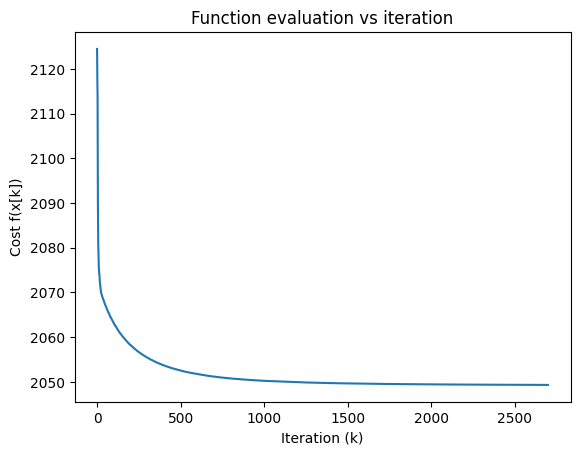

In [19]:
ell = LogLikelihoodLogistic(X[:N_train], y[:N_train])
f_iter = np.array([ell.f(x_i) for x_i in res.steps])
fig = plt.figure()
plt.plot(f_iter)
plt.title("Function evaluation vs iteration")
plt.xlabel("Iteration (k)")
plt.ylabel("Cost f(x[k])")
fig.savefig(DATA_DIR / 'cost_eval.png')
    


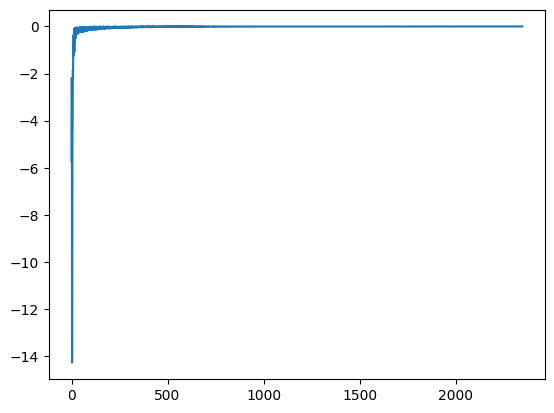

In [135]:
plt.figure()
plt.plot(np.diff(f_iter))

In [137]:
res.solution

array([ 0.07586921,  0.04975827, -0.05226353, -0.1266555 ,  0.04083131,
        0.03131375, -0.07261353,  0.00321037, -0.08552396, -0.06015927,
        0.02361989, -0.01129577, -0.02391278,  0.05750825, -0.00757365,
       -0.04522009,  0.0922744 ,  0.00102577,  0.00484013,  0.06914503,
        0.0603164 , -0.05296877,  0.12877386, -0.08270653, -0.05943253,
        0.11404542, -0.03199153, -0.05505382,  0.02582704, -0.03789365,
        0.06507323, -0.00590622, -0.07067378,  0.05118466,  0.01755699,
       -0.08290268,  0.02064266, -0.10809732,  0.12325599,  0.06681287,
       -0.00336404, -0.08745445,  0.00129815,  0.07803616, -0.03338325,
        0.04337312, -0.05887014,  0.13525216, -0.08179963,  0.07645053,
       -0.18556667, -0.07629123,  0.01640805, -0.03421094,  0.1199978 ,
       -0.05434214,  0.00163782])

In [146]:
ell_train = LL(X[:N_train], y[:N_train])
ell_test = LL(X[N_train:], y[N_train:])
def classify(ell, sol):
    prob = np.array([sigmoid(ell.alpha(i, sol)) for i in range(ell.X.shape[0])])
    return np.where(prob > 0.5, 1, -1)

class_train = classify(ell_train, res.solution)
print(class_train.shape)
misclass_train = np.sum(class_train != y[N_train])
print(misclass_train / N_train)

(3065,)
0.401305057096248


Text(0.5, 1.0, 't history')

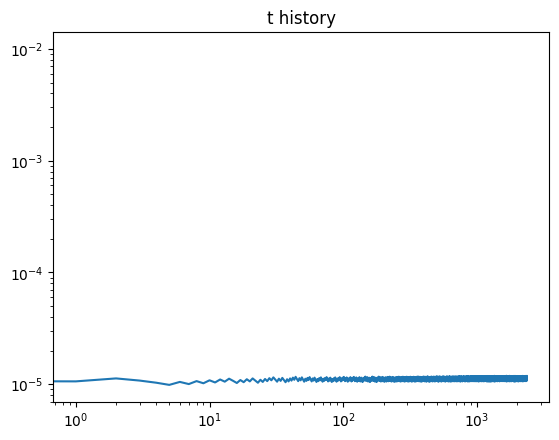

In [136]:
plt.figure()
plt.loglog(res.t_history)
plt.title("t history")

In [61]:
from cvx_opt.hw6 import test_gradient, plot_errors

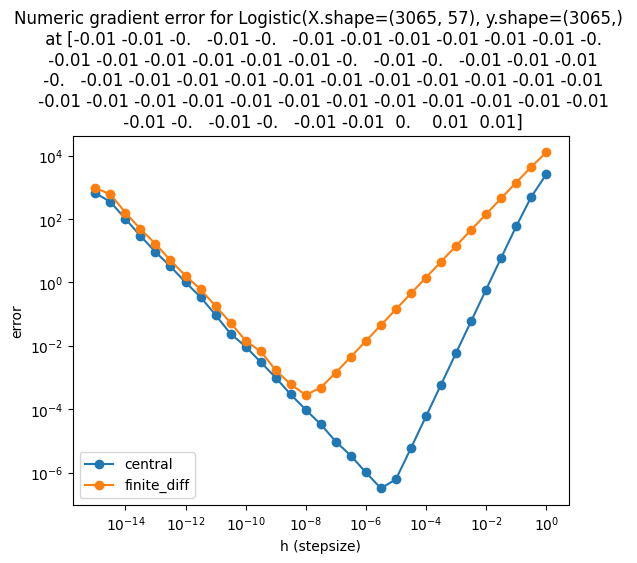

In [116]:
ell = LogLikelihoodLogistic(X[:N_train], y[:N_train])
e = test_gradient(ell.f, ell.grad, res.steps[1])
plot_errors(e, str(ell), None)

In [74]:
max([ell.alpha(i, res.solution) for i in range(N_train)])

np.float64(3.505898631986234)

In [48]:
res.solution

array([1.56998989e-02, 3.84859322e-02, 4.23125115e-02, 5.60019761e-03,
       4.88608069e-02, 1.39746444e-02, 1.75544015e-02, 1.55965003e-02,
       1.31291113e-02, 3.69332866e-02, 9.28335319e-03, 8.17240273e-02,
       1.45033111e-02, 9.11824909e-03, 7.96418812e-03, 3.72109617e-02,
       2.18312647e-02, 2.85571721e-02, 2.54668069e-01, 1.46267222e-02,
       1.26366341e-01, 1.86459230e-02, 1.66588368e-02, 1.44074173e-02,
       8.49393880e-02, 4.00402455e-02, 1.21273130e-01, 2.04478925e-02,
       1.67088683e-02, 1.61418442e-02, 1.07701239e-02, 8.40196414e-03,
       1.36869630e-02, 8.53204616e-03, 1.82798589e-02, 1.46850923e-02,
       2.01018410e-02, 1.99042164e-03, 9.93793257e-03, 1.11870535e-02,
       7.44969707e-03, 2.10424340e-02, 6.43655828e-03, 1.17982722e-02,
       4.12535105e-02, 2.78909187e-02, 1.21910198e-03, 5.10405146e-03,
       5.88154167e-03, 2.16044550e-02, 2.23340817e-03, 3.98972387e-02,
       1.19197655e-02, 7.91348949e-03, 8.86925961e-01, 8.68197402e+00,
      

In [290]:
res.converged

True

In [258]:
order = np.random.permutation(5)

In [259]:
np.arange(5)[order]

array([1, 3, 0, 4, 2])

In [260]:
order[order]

array([3, 4, 1, 2, 0])